2026-03-21 13:10:21,502 - INFO - Total tickers loaded: 503
2026-03-21 13:10:21,505 - INFO - Downloading batch 0 to 50
2026-03-21 13:10:23,505 - INFO - Downloading batch 50 to 100
2026-03-21 13:10:25,939 - INFO - Downloading batch 100 to 150
2026-03-21 13:10:28,207 - ERROR - 
1 Failed download:
2026-03-21 13:10:28,207 - ERROR - ['DUMMYSKFIN.NS']: YFTzMissingError('possibly delisted; no timezone found')
2026-03-21 13:10:28,440 - INFO - Downloading batch 150 to 200
2026-03-21 13:10:30,589 - ERROR - 
2 Failed downloads:
2026-03-21 13:10:30,589 - ERROR - ['DUMMYTATAM.NS', 'DUMMYDBRLT.NS']: YFTzMissingError('possibly delisted; no timezone found')
2026-03-21 13:10:30,741 - INFO - Downloading batch 200 to 250
2026-03-21 13:10:33,095 - INFO - Downloading batch 250 to 300
2026-03-21 13:10:35,424 - INFO - Downloading batch 300 to 350
2026-03-21 13:10:37,627 - INFO - Downloading batch 350 to 400
2026-03-21 13:10:39,957 - INFO - Downloading batch 400 to 450
2026-03-21 13:10:42,915 - ERROR - 
1 Fail


Top Beta Expansion Stocks:
               Current Beta  Past Beta  Beta Change
FIVESTAR.NS        1.068642   0.009403     1.059239
MRPL.NS            1.617387   0.822239     0.795148
EICHERMOT.NS       1.373641   0.680278     0.693363
JKTYRE.NS          1.566315   0.885744     0.680572
GODREJCP.NS        0.765899   0.091902     0.673996
M&M.NS             1.560278   0.913084     0.647194
ESCORTS.NS         1.178340   0.554036     0.624304
ABSLAMC.NS         1.450547   0.840885     0.609662
BLUESTARCO.NS      0.952773   0.364390     0.588383
OLECTRA.NS         1.992731   1.441065     0.551666


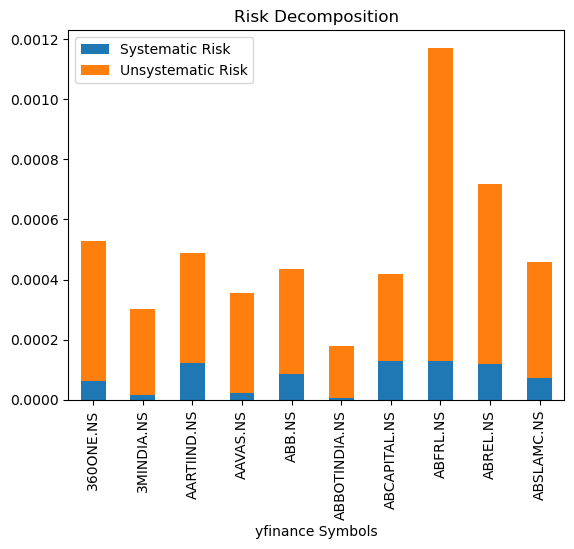

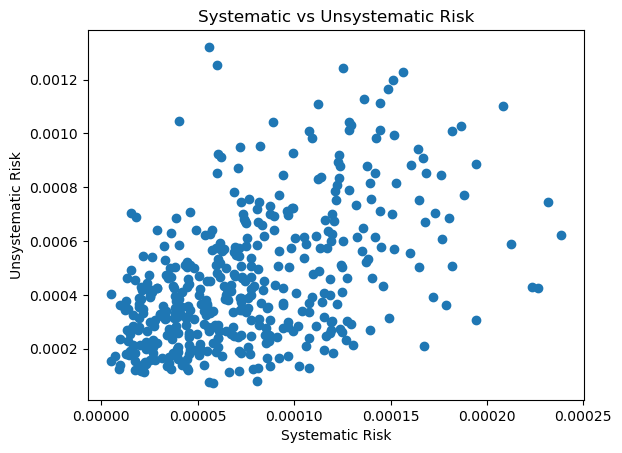

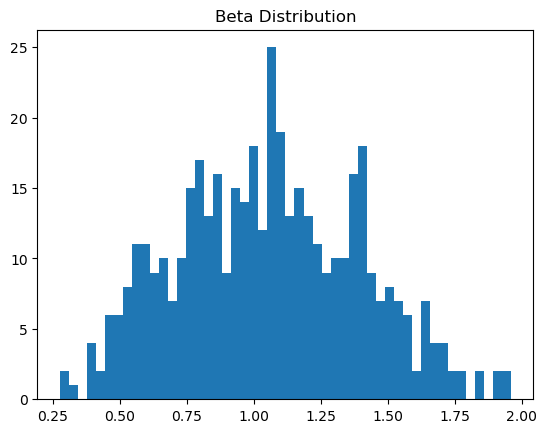

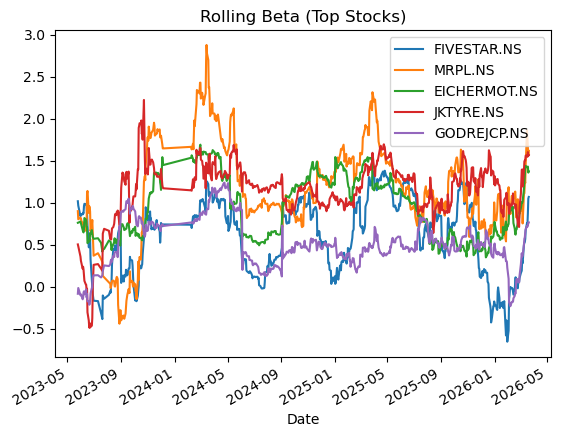

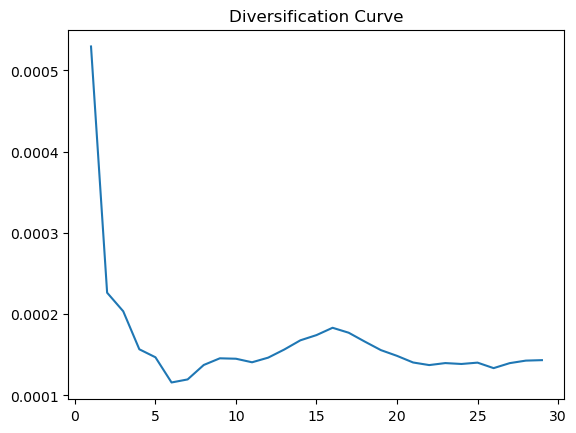

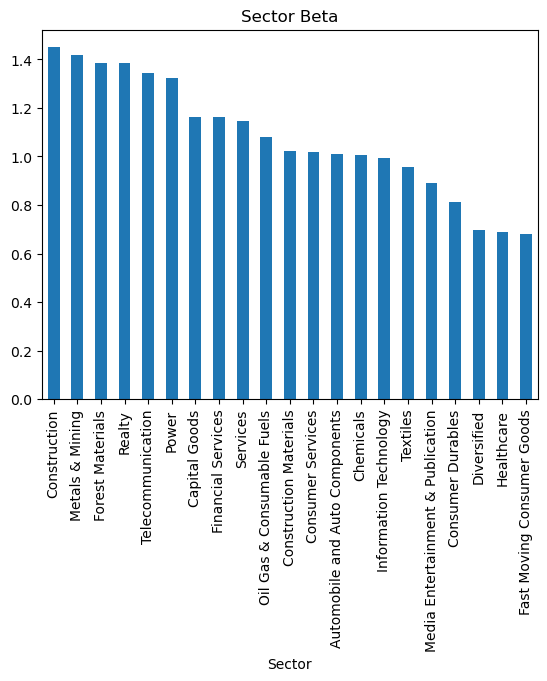

In [2]:
# =========================
# IMPORTS
# =========================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

# =========================
# WARNING & LOGGING CONTROL
# =========================
warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# =========================
# CONFIG
# =========================
file_path = r"C:\Users\navon\Downloads\ind_nifty500list.csv"
ticker_col = "yfinance Symbols"
sector_col = "Industry"
market = "^NSEI"
start_date = "2022-01-01"
batch_size = 50

# =========================
# STEP 1: LOAD TICKERS
# =========================
try:
    df = pd.read_csv(file_path)
except Exception as e:
    raise Exception(f"Error loading CSV: {e}")

df[ticker_col] = df[ticker_col].astype(str).str.strip()
df = df.dropna(subset=[ticker_col, sector_col])

tickers = df[ticker_col].unique().tolist()
logging.info(f"Total tickers loaded: {len(tickers)}")

# =========================
# STEP 2: ROBUST DOWNLOAD
# =========================
def download_in_batches(tickers, batch_size=50):
    all_data = []
    failed_tickers = []

    for i in range(0, len(tickers), batch_size):
        batch = tickers[i:i+batch_size]
        logging.info(f"Downloading batch {i} to {i+len(batch)}")

        try:
            raw = yf.download(
                batch,
                start=start_date,
                progress=False,
                auto_adjust=True,
                threads=True
            )

            if raw.empty:
                failed_tickers.extend(batch)
                continue

            if isinstance(raw.columns, pd.MultiIndex):
                data = raw["Close"]
            else:
                data = raw[["Close"]]
                data.columns = batch

            missing = list(set(batch) - set(data.columns))
            failed_tickers.extend(missing)

            all_data.append(data)

        except Exception as e:
            logging.warning(f"Batch failed: {e}")
            failed_tickers.extend(batch)

    if not all_data:
        raise Exception("No data downloaded. Check internet or ticker list.")

    final_data = pd.concat(all_data, axis=1)

    logging.info(f"Download complete. Failed tickers: {len(failed_tickers)}")
    return final_data, failed_tickers

stock_data, failed = download_in_batches(tickers, batch_size)

# =========================
# MARKET DATA
# =========================
try:
    market_data = yf.download(
        market,
        start=start_date,
        progress=False,
        auto_adjust=True
    )[["Close"]]
    market_data.columns = [market]
except Exception as e:
    raise Exception(f"Market data download failed: {e}")

# =========================
# COMBINE DATA
# =========================
data = stock_data.join(market_data, how="inner")
logging.info(f"Raw data shape: {data.shape}")

# =========================
# STEP 3: CLEAN DATA
# =========================
data = data.dropna(axis=1, thresh=int(0.7 * len(data)))
logging.info(f"After cleaning: {data.shape}")

# =========================
# STEP 4: RETURNS
# =========================
returns = data.pct_change(fill_method=None)

returns = returns.dropna(axis=1, thresh=int(0.7 * len(returns)))
returns = returns.dropna()

if returns.empty:
    raise Exception("Returns dataframe is empty after cleaning.")

logging.info(f"Returns shape: {returns.shape}")

# =========================
# STEP 5: BETA
# =========================
market_returns = returns[market]
stock_returns = returns.drop(columns=[market])

market_var = market_returns.var()

if market_var == 0:
    raise Exception("Market variance is zero. Cannot compute beta.")

cov_with_market = stock_returns.apply(lambda x: x.cov(market_returns))
betas = cov_with_market / market_var

betas = betas.dropna()
stock_returns = stock_returns[betas.index]

logging.info(f"Stocks with beta: {len(betas)}")

# =========================
# STEP 6: RISK DECOMPOSITION
# =========================
risk_df = pd.DataFrame(index=stock_returns.columns)

for stock in stock_returns.columns:
    try:
        total_var = stock_returns[stock].var()
        beta = betas[stock]

        systematic = (beta ** 2) * market_var
        unsystematic = total_var - systematic

        risk_df.loc[stock, "Beta"] = beta
        risk_df.loc[stock, "Total Risk"] = total_var
        risk_df.loc[stock, "Systematic Risk"] = systematic
        risk_df.loc[stock, "Unsystematic Risk"] = unsystematic
    except Exception as e:
        logging.warning(f"Error processing {stock}: {e}")

risk_df["Systematic %"] = (
    risk_df["Systematic Risk"] / risk_df["Total Risk"]
) * 100

# =========================
# STEP 7: MERGE SECTOR
# =========================
risk_df = risk_df.merge(
    df[[ticker_col, sector_col]],
    left_index=True,
    right_on=ticker_col,
    how="left"
)

risk_df = risk_df.rename(columns={sector_col: "Sector"})
logging.info(f"Final dataset shape: {risk_df.shape}")

# =========================
# STEP 8: ROLLING BETA (OPTIMIZED)
# =========================
window = 60
rolling_dict = {}

var = market_returns.rolling(window).var()

for stock in stock_returns.columns:
    try:
        cov = stock_returns[stock].rolling(window).cov(market_returns)
        rolling_dict[stock] = cov / var
    except Exception as e:
        logging.warning(f"Rolling beta failed for {stock}: {e}")

rolling_beta = pd.DataFrame(rolling_dict)
logging.info("Rolling beta computed")

# =========================
# STEP 9: BETA SIGNAL
# =========================
try:
    recent_beta = rolling_beta.iloc[-1]
    past_beta = rolling_beta.iloc[-20]

    beta_change = recent_beta - past_beta

    beta_signal = pd.DataFrame({
        "Current Beta": recent_beta,
        "Past Beta": past_beta,
        "Beta Change": beta_change
    })

    top_expansion = beta_signal.sort_values("Beta Change", ascending=False).head(10)

    print("\nTop Beta Expansion Stocks:")
    print(top_expansion)

except Exception as e:
    logging.warning(f"Beta signal failed: {e}")

# =========================
# =========================
# CHARTS
# =========================
# =========================

try:
    # Risk Decomposition
    risk_df.set_index(ticker_col)[["Systematic Risk", "Unsystematic Risk"]].head(10).plot(kind="bar", stacked=True)
    plt.title("Risk Decomposition")
    plt.show()

    # Scatter
    plt.figure()
    plt.scatter(risk_df["Systematic Risk"], risk_df["Unsystematic Risk"])
    plt.xlabel("Systematic Risk")
    plt.ylabel("Unsystematic Risk")
    plt.title("Systematic vs Unsystematic Risk")
    plt.show()

    # Beta Distribution
    plt.figure()
    plt.hist(risk_df["Beta"], bins=50)
    plt.title("Beta Distribution")
    plt.show()

    # Rolling Beta Plot
    top_stocks = top_expansion.index[:5]
    rolling_beta[top_stocks].plot()
    plt.title("Rolling Beta (Top Stocks)")
    plt.show()

    # Diversification
    portfolio_risk = []
    stocks_list = list(stock_returns.columns)

    for i in range(1, 30):
        subset = stocks_list[:i]
        weights = np.ones(i) / i
        cov_matrix = stock_returns[subset].cov()
        port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_risk.append(port_var)

    plt.figure()
    plt.plot(range(1, 30), portfolio_risk)
    plt.title("Diversification Curve")
    plt.show()

    # Sector Beta
    sector_analysis = risk_df.groupby("Sector")["Beta"].mean().sort_values(ascending=False)
    sector_analysis.plot(kind="bar")
    plt.title("Sector Beta")
    plt.show()

except Exception as e:
    logging.warning(f"Chart generation failed: {e}")


Average Turnover: 0.03571428571428571


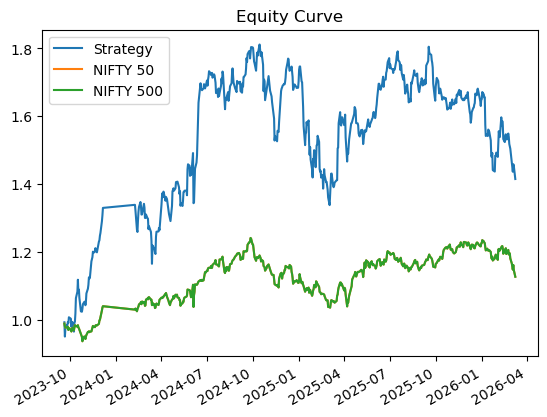

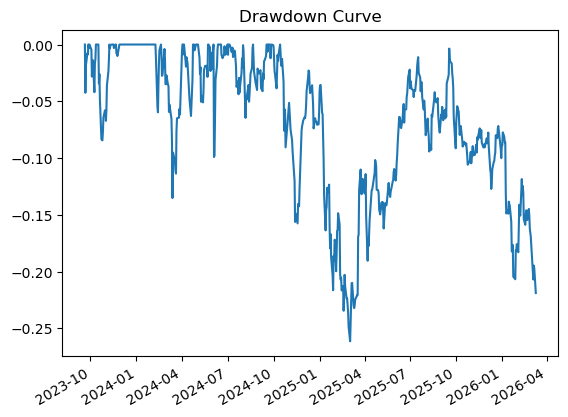


Excel report generated: backtest_output.xlsx


In [4]:
# =========================
# STEP 10: ADVANCED BACKTEST + REPORTING
# =========================

rebalance_period = 20
top_n = 10
transaction_cost = 0.001

portfolio_returns = []
dates = []

prev_weights = None
turnovers = []
trade_log = []

for i in range(60, len(rolling_beta) - rebalance_period, rebalance_period):
    
    try:
        date = rolling_beta.index[i]

        # Signal
        recent = rolling_beta.iloc[i]
        past = rolling_beta.iloc[i - 20]
        beta_change = recent - past
        
        selected = beta_change.sort_values(ascending=False).head(top_n).index
        weights = pd.Series(1 / top_n, index=selected)

        # Turnover calculation
        if prev_weights is not None:
            combined = weights.add(prev_weights, fill_value=0)
            turnover = np.abs(weights - prev_weights).sum()
            
            added = list(set(weights.index) - set(prev_weights.index))
            removed = list(set(prev_weights.index) - set(weights.index))
        else:
            turnover = 1.0
            added = list(weights.index)
            removed = []

        cost = turnover * transaction_cost
        turnovers.append(turnover)

        # Store trades
        trade_log.append({
            "Date": date,
            "Added": ", ".join(added),
            "Removed": ", ".join(removed),
            "Turnover": turnover
        })

        # Returns
        future_returns = returns[selected].iloc[i:i+rebalance_period]
        daily_returns = future_returns.mean(axis=1)

        daily_returns.iloc[0] -= cost

        portfolio_returns.extend(daily_returns.values)
        dates.extend(future_returns.index)

        prev_weights = weights

    except Exception as e:
        print(f"Skipping period: {e}")

portfolio_returns = pd.Series(portfolio_returns, index=dates)

# =========================
# BENCHMARKS
# =========================
nifty50 = market_returns.loc[portfolio_returns.index]

try:
    nifty500_data = yf.download("^CRSLDX", start=start_date, progress=False, auto_adjust=True)["Close"]
    nifty500 = nifty500_data.pct_change().dropna().loc[portfolio_returns.index]
except:
    nifty500 = nifty50.copy()

# =========================
# PERFORMANCE METRICS
# =========================
def performance_summary(returns):

    cumulative = (1 + returns).cumprod()
    total_return = cumulative.iloc[-1] - 1
    annual_return = (1 + total_return) ** (252 / len(returns)) - 1
    volatility = returns.std() * np.sqrt(252)
    sharpe = annual_return / volatility

    downside = returns[returns < 0]
    sortino = annual_return / (downside.std() * np.sqrt(252)) if len(downside) > 0 else np.nan

    drawdown = cumulative / cumulative.cummax() - 1
    max_dd = drawdown.min()

    calmar = annual_return / abs(max_dd)

    return {
        "Total Return": total_return,
        "Annual Return": annual_return,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar
    }

strategy_metrics = performance_summary(portfolio_returns)
nifty50_metrics = performance_summary(nifty50)
nifty500_metrics = performance_summary(nifty500)

# =========================
# TURNOVER METRICS
# =========================
avg_turnover = np.mean(turnovers)

print("\nAverage Turnover:", avg_turnover)

# =========================
# EQUITY CURVE
# =========================
strategy_curve = (1 + portfolio_returns).cumprod()
nifty50_curve = (1 + nifty50).cumprod()
nifty500_curve = (1 + nifty500).cumprod()

# =========================
# DRAWDOWN CURVE
# =========================
drawdown_curve = strategy_curve / strategy_curve.cummax() - 1

# =========================
# PLOTS
# =========================

# Equity Curve
plt.figure()
strategy_curve.plot(label="Strategy")
nifty50_curve.plot(label="NIFTY 50")
nifty500_curve.plot(label="NIFTY 500")
plt.legend()
plt.title("Equity Curve")
plt.show()

# Drawdown Curve
plt.figure()
drawdown_curve.plot()
plt.title("Drawdown Curve")
plt.show()

# =========================
# EXPORT TO EXCEL
# =========================
with pd.ExcelWriter("backtest_output.xlsx") as writer:

    # Metrics
    metrics_df = pd.DataFrame({
        "Strategy": strategy_metrics,
        "NIFTY 50": nifty50_metrics,
        "NIFTY 500": nifty500_metrics
    })
    metrics_df.to_excel(writer, sheet_name="Performance")

    # Trade log
    pd.DataFrame(trade_log).to_excel(writer, sheet_name="Trades")

    # Equity curve
    pd.DataFrame({
        "Strategy": strategy_curve,
        "NIFTY 50": nifty50_curve,
        "NIFTY 500": nifty500_curve
    }).to_excel(writer, sheet_name="Equity Curve")

    # Drawdown
    drawdown_curve.to_frame("Drawdown").to_excel(writer, sheet_name="Drawdown")

    # Turnover
    pd.DataFrame({
        "Turnover": turnovers
    }).to_excel(writer, sheet_name="Turnover")

print("\nExcel report generated: backtest_output.xlsx")